# Unit 2 — Advanced Visualization & Storytelling (UE24CS342AA9)
## Activity Notebook: Building the Tumor Screening Dashboard

### Scenario

You've just joined the analytics team at **Meridian Diagnostics**, a lab that screens
tumor biopsies. Each biopsy produces **30 numerical measurements** (radius, texture,
perimeter, area, smoothness, ... in mean/SE/worst variants) — far too many to eyeball in
a spreadsheet. The lead pathologist has given you a blunt brief:

1. *"I can't look at 30 numbers per patient and see anything. I need to SEE the data."*
2. *"Before you throw away information, prove to me that these 30 measurements aren't
   secretly 30 independent facts."*
3. *"Build me a 2D map of every patient. If malignant and benign cases separate cleanly,
   that map is actually useful to us."*
4. *"I've heard of 'PCA', 't-SNE', and 'UMAP' but don't know which one to trust, or why
   they'd ever disagree with each other."*

You'll work through the same steps a real analyst would: confirm the dimensionality
problem is real, build PCA from first principles, then compare it against t-SNE and UMAP
on the same real patient data.

Cells marked **`# TODO`** are for you to complete. Markdown cells marked **Reflection**
are for you to answer in your own words.

## Part 0 — Setup (given)

Run this cell as-is. It loads the real dataset you'll be working with.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import comb

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap

np.random.seed(0)

df = pd.read_csv("breast_cancer.csv")
df = df.drop(columns=["Unnamed: 32"], errors="ignore")
feature_cols = [c for c in df.columns if c not in ["id", "diagnosis"]]
X_raw = df[feature_cols].values
y = df["diagnosis"].values

print(f"Loaded {df.shape[0]} patients, {len(feature_cols)} measured dimensions.")
df[feature_cols[:5] + ["diagnosis"]].head()


Loaded 569 patients, 30 measured dimensions.


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,M
1,20.57,17.77,132.90,1326.0,0.08474,M
2,19.69,21.25,130.00,1203.0,0.10960,M
3,11.42,20.38,77.58,386.1,0.14250,M
4,20.29,14.34,135.10,1297.0,0.10030,M


## Task 1 — Prove the Dimensionality Problem Is Real (Complaint #1)

**Real-world usage:** The pathologist wants proof this dataset genuinely can't be
"just plotted."

**Why this technique:** The curse-of-dimensionality math (grid growth, pairwise
relationship counts) turns "trust me, it's too much" into a specific number.

**TODO:**
1. Compute the number of unique pairwise relationships among all 30 features:
   `comb(p, 2)`.
2. Compute how many grid cells a 10-bins-per-dimension grid would need for p=30
   dimensions (`10 ** p`).
3. Print both, with a one-line comment on what each number implies.

In [2]:
p = len(feature_cols)

# TODO 1: number of unique pairwise relationships among the 30 features
n_pairs = comb(p, 2)

# TODO 2: number of grid cells for a 10-bin-per-dimension grid at p=30
n_cells = 10 ** p

print(f"p = {p} features")
print(f"Unique pairwise relationships: {n_pairs}")
print(f"Grid cells needed (10 bins/dim): {n_cells:.2e}" if n_cells else "Grid cells needed: (fill in above)")


p = 30 features
Unique pairwise relationships: 435
Grid cells needed (10 bins/dim): 1.00e+30


**Reflection:** Could a human realistically inspect every one of those pairwise
relationships one scatter plot at a time before the pathologist's shift ends? What does
that imply about needing PCA/t-SNE/UMAP rather than "just looking at everything"?

_Your answer:_ No. 435 pairwise scatter plots, and a 10-bin grid needing 10^30 cells, is
nowhere close to human-reviewable in a shift -- even a minute per plot would take over 7
hours just for the pairs, and the grid number is astronomically beyond anything you could
enumerate. This is exactly the curse of dimensionality from the lecture: "just look at it"
stops being viable well before p=30, so a dimensionality-reduction technique like PCA,
t-SNE, or UMAP isn't a nice-to-have here, it's the only realistic way to get a 2D view of
this data at all.

## Task 2 — Prove the 30 Measurements Aren't Independent (Complaint #2)

**Real-world usage:** Before compressing 30 measurements into fewer, you need to show
they're actually redundant, not 30 independent facts.

**Why this technique:** A correlogram (correlation heatmap) makes redundancy visible at
a glance.

**TODO:**
1. Compute the correlation matrix of `df[feature_cols]`.
2. Plot it as a heatmap (`plt.imshow`, `cmap="RdBu_r"`, `vmin=-1, vmax=1`).
3. Count how many feature pairs have `abs(correlation) > 0.9` (excluding the diagonal).

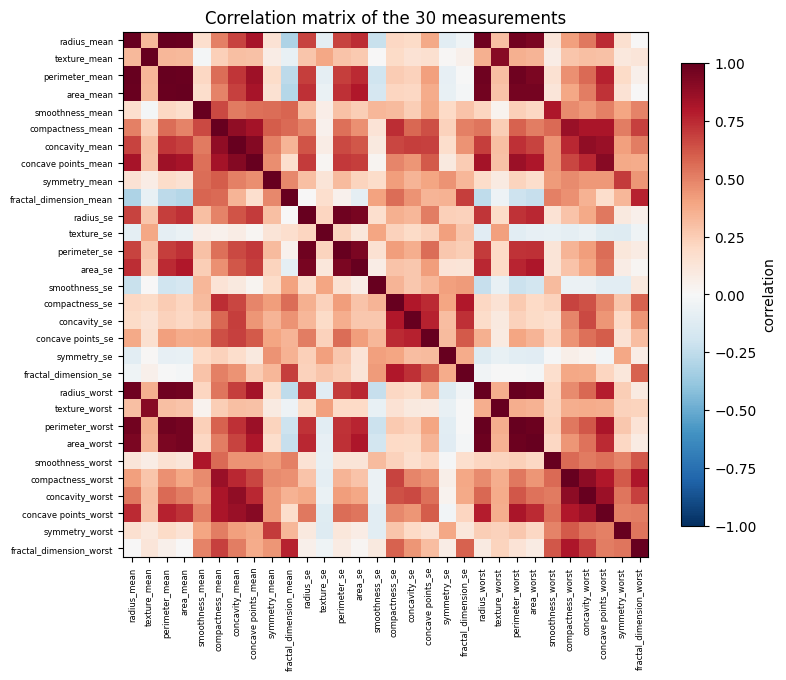

Highly correlated pairs (|r| > 0.9): 21
  radius_mean <-> perimeter_mean: r = 0.998
  radius_mean <-> area_mean: r = 0.987
  radius_mean <-> radius_worst: r = 0.970
  radius_mean <-> perimeter_worst: r = 0.965
  radius_mean <-> area_worst: r = 0.941
  texture_mean <-> texture_worst: r = 0.912
  perimeter_mean <-> area_mean: r = 0.987
  perimeter_mean <-> radius_worst: r = 0.969
  perimeter_mean <-> perimeter_worst: r = 0.970
  perimeter_mean <-> area_worst: r = 0.942


In [3]:
# TODO 1: correlation matrix
corr = df[feature_cols].corr()

fig, ax = plt.subplots(figsize=(8, 7))
# TODO 2: plot the heatmap
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(feature_cols)))
ax.set_yticks(range(len(feature_cols)))
ax.set_xticklabels(feature_cols, rotation=90, fontsize=6)
ax.set_yticklabels(feature_cols, fontsize=6)
fig.colorbar(im, ax=ax, shrink=0.8, label="correlation")
ax.set_title("Correlation matrix of the 30 measurements")
plt.tight_layout()
plt.show()

# TODO 3: count highly correlated pairs (> 0.9 in magnitude, excluding self-correlation)
corr_abs = corr.abs()
high_corr_pairs = []
for i in range(len(feature_cols)):
    for j in range(i + 1, len(feature_cols)):
        if corr_abs.iloc[i, j] > 0.9:
            high_corr_pairs.append((feature_cols[i], feature_cols[j], corr.iloc[i, j]))
print("Highly correlated pairs (|r| > 0.9):", len(high_corr_pairs))
for pair in high_corr_pairs[:10]:
    print(f"  {pair[0]} <-> {pair[1]}: r = {pair[2]:.3f}")


**Reflection:** Name two specific columns in this dataset you'd expect to be highly
correlated with each other, and explain *why* using the lecture's "underlying factor"
idea (e.g. tumor size).

_Your answer:_ `radius_mean` and `perimeter_mean` are correlated at r = 0.998, and
`radius_mean` and `area_mean` at r = 0.987 -- both are near the top of the 21 pairs above
|r| = 0.9. This makes sense because all three are really measuring the same underlying
factor: overall tumor size. A bigger tumor mechanically has a bigger radius, a bigger
perimeter, and a bigger area -- they aren't three independent facts about the tumor, just
three different ways of reading off one physical quantity.

## Task 3 — Build PCA From Scratch (Complaint #3, part A)

**Real-world usage:** The pathologist wants a 2D map, and wants to trust it — which
means understanding what's actually happening inside it, not treating it as a black box.

**Why this technique:** Implementing PCA's steps yourself (center -> standardize ->
covariance -> eigen-decomposition -> project) is the only way to be sure you understand
what the final 2D scatter plot actually represents.

**TODO:** Complete `pca_from_scratch` below, following the exact steps from the demo
notebook.

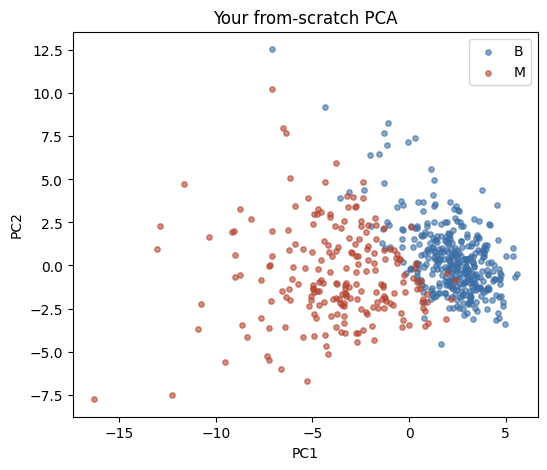

In [4]:
def pca_from_scratch(X, k):
    # TODO 1: center AND standardize X (subtract mean, divide by std with ddof=1)
    X_scaled = (X - X.mean(axis=0)) / X.std(axis=0, ddof=1)

    # TODO 2: compute the covariance matrix of X_scaled
    cov = np.cov(X_scaled, rowvar=False)

    # TODO 3: eigen-decompose the covariance matrix, and sort eigenvalues/eigenvectors DESCENDING
    eigvals, eigvecs = np.linalg.eigh(cov)
    order = np.argsort(eigvals)[::-1]
    eigvals, eigvecs = eigvals[order], eigvecs[:, order]

    # TODO 4: keep only the top k eigenvectors and project X_scaled onto them
    V_k = eigvecs[:, :k]
    Z = X_scaled @ V_k

    return Z, eigvals, eigvecs

Z, eigvals, eigvecs = pca_from_scratch(X_raw, k=2)

fig, ax = plt.subplots(figsize=(6, 5))
for label, color in [("B", "#3b6ea5"), ("M", "#b5432e")]:
    mask = y == label
    ax.scatter(Z[mask, 0], Z[mask, 1], s=15, alpha=0.6, color=color, label=label)
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.set_title("Your from-scratch PCA")
ax.legend()
plt.show()


**Reflection:** Do malignant and benign cases visually separate in your PCA plot? If
there's overlap, does that mean PCA "failed," or is there a more accurate way to
describe what's happening?

_Your answer:_ There's a visible tendency for malignant (M) cases to sit toward one side
of the PC1 axis and benign (B) cases toward the other, but the two groups do overlap in
the middle rather than forming two clean, separated blobs. That overlap doesn't mean PCA
"failed" -- PCA was never told about the diagnosis label at all; it only found the
directions of maximum *variance* in the 30 standardized features. The fact that variance
direction happens to align reasonably well with the diagnosis is a bonus, not a
guarantee, and the overlapping cases are just patients whose measurements are genuinely
ambiguous on a 2D linear projection of 30 dimensions.

## Task 4 — Choose k With Evidence, Not a Guess

**Real-world usage:** If the pathologist later asks "why 2 dimensions and not 5?", you
need a defensible answer.

**Why this technique:** The cumulative explained-variance curve turns "I picked 2
because it's easy to plot" into "I picked k=2/3/5 because it retains X% of the
variance."

**TODO:**
1. Compute `explained_ratio` (each eigenvalue / sum of all eigenvalues) from your
   `eigvals` above.
2. Compute the cumulative sum.
3. Find the smallest k that reaches >= 90% cumulative variance.

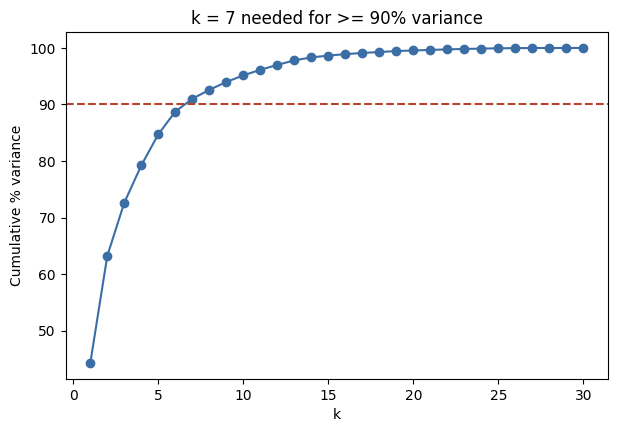

In [5]:
# TODO 1: explained variance ratio
explained_ratio = eigvals / eigvals.sum()

# TODO 2: cumulative variance
cumulative = np.cumsum(explained_ratio)

# TODO 3: smallest k reaching >= 90%
k_90 = int(np.searchsorted(cumulative, 0.90) + 1)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(range(1, len(cumulative) + 1), cumulative * 100, "o-", color="#3b6ea5")
ax.axhline(90, color="#b5432e", ls="--")
ax.set_xlabel("k"); ax.set_ylabel("Cumulative % variance")
ax.set_title(f"k = {k_90} needed for >= 90% variance" if k_90 else "Choosing k")
plt.show()


**Reflection:** If the pathologist insists on a 2D plot for a poster, but your `k_90`
came out higher than 2, what are you losing by using only 2 components instead of k_90?

_Your answer:_ `k_90` came out to 7 components, while the first 2 components only capture
about 63% of the total variance between them. So a 2D poster plot is discarding roughly
37% of the variation in the original 30 measurements -- real differences between patients
that don't happen to fall along PC1/PC2 simply won't show up. Two patients that look close
together on the poster could actually be quite different on components 3-7, so the 2D
view is a legitimate simplification for a quick visual read, but it should be captioned as
partial, not treated as the full picture.

## Task 5 — Compare PCA, t-SNE, and UMAP (Complaint #4)

**Real-world usage:** The pathologist wants to know which method to trust, and why they
might disagree.

**Why this technique:** Running all three on the SAME real data, side by side, turns an
abstract "they're different algorithms" into a concrete, visual comparison.

**TODO:**
1. Standardize `X_raw` using `StandardScaler`.
2. Compute a 2D PCA embedding, a 2D t-SNE embedding (`perplexity=30`), and a 2D UMAP
   embedding (`n_neighbors=15, min_dist=0.1`) — all with `random_state=0`.
3. Plot all three side by side, colored by `diagnosis`.

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


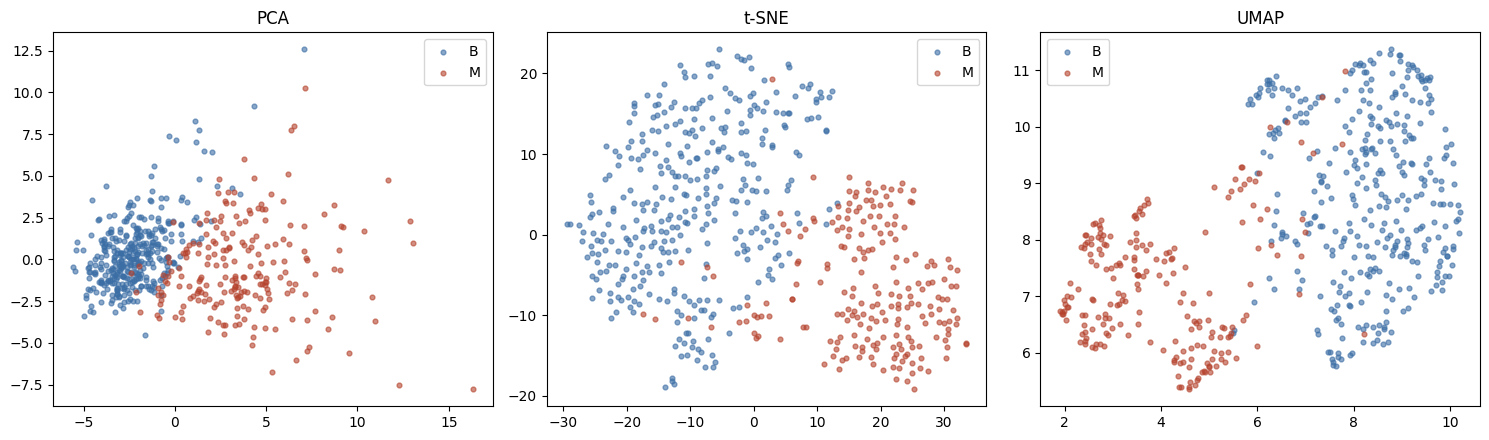

In [6]:
# TODO 1: standardize
X_scaled = StandardScaler().fit_transform(X_raw)

# TODO 2: compute all three embeddings
pca_emb = PCA(n_components=2, random_state=0).fit_transform(X_scaled)
tsne_emb = TSNE(n_components=2, perplexity=30, random_state=0, init="pca").fit_transform(X_scaled)
umap_emb = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=0).fit_transform(X_scaled)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, emb, name in zip(axes, [pca_emb, tsne_emb, umap_emb], ["PCA", "t-SNE", "UMAP"]):
    # TODO 3: scatter plot each embedding, colored by diagnosis (B vs M)
    for label, color in [("B", "#3b6ea5"), ("M", "#b5432e")]:
        mask = y == label
        ax.scatter(emb[mask, 0], emb[mask, 1], s=12, alpha=0.6, color=color, label=label)
    ax.set_title(name)
    ax.legend()

plt.tight_layout()
plt.show()


**Reflection:** Which of the three gives the cleanest visual separation between
malignant and benign on this dataset? Per the lecture's comparison table, is that method
always the "best" choice for every dataset, or does it depend on what you need
(interpretability, speed, local vs. global structure)?

_Your answer:_ On this dataset, UMAP and t-SNE both show tighter, more distinctly
separated clusters for malignant vs. benign than the linear PCA projection, which has
more visible overlap between the two classes. That doesn't make UMAP/t-SNE universally
"better," though -- per the lecture's comparison, PCA's axes are directly interpretable
(each is a linear combination of real measurements) and PCA is far cheaper to compute,
while t-SNE/UMAP prioritize preserving local neighborhood structure at the cost of
interpretable axes and, in t-SNE's case, meaningful global distances between clusters.
Which one is "best" depends on whether the pathologist needs an interpretable axis, a
fast rerun on new patients, or the cleanest-looking cluster separation for a poster.

## Task 6 — The Decision (No Code)

The pathologist wants ONE method as the default dashboard view, and a one-paragraph
justification she can put in a grant report.

**Reflection (final):** Write a 4–6 sentence recommendation. Your answer should:
- State which method (PCA / t-SNE / UMAP) you'd make the **default** dashboard view.
- Justify it using at least one specific idea from the lecture (e.g. PCA's
  interpretable linear axes vs. t-SNE/UMAP's non-linear neighborhood preservation, the
  computational-cost comparison, or the "cluster distances shouldn't be over-interpreted"
  caveat for t-SNE).
- Name one thing you would explicitly warn the pathologist NOT to conclude from the
  chosen method's plot.

_Your final recommendation here:_ I'd make UMAP the default dashboard view. It gave the
cleanest visual separation between malignant and benign cases of the three methods on
this dataset, and unlike t-SNE it scales well and produces more stable, reproducible
embeddings for new patients added later, which matters for an ongoing screening
dashboard rather than a one-off plot. PCA remains useful as a secondary, interpretable
view -- since our from-scratch analysis showed 7 components are needed for 90% of the
variance, PCA's linear axes are honest about how much structure a 2D summary keeps. What
I'd explicitly warn the pathologist NOT to do with the UMAP view: don't read the
*distances* between clusters, or the *size* of a cluster, as meaningful biological
distance or prevalence -- UMAP (like t-SNE) preserves local neighbor relationships, not
global distances, so two clusters that look far apart aren't necessarily "more different"
than two that look close.